# Benchmarking

In [17]:
# Import python modules
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Determine the absolute path to the src directory (one level up from notebooks)
module_path = os.path.abspath(os.path.join("..", "src"))
if module_path not in sys.path:
    sys.path.append(module_path)

In [18]:
# Import custom modules
import plotting
import utils

In [19]:
BASE_FOLDER = os.path.dirname(os.getcwd())
RUNS_FOLDER = os.path.join(BASE_FOLDER, "runs")
BATCH_RUNS_FOLDER = os.path.join(RUNS_FOLDER, "batch_runs")

DATA_FOLDER = os.path.join(BASE_FOLDER, "data")
FOR_THE_REPORT_FOLDER = os.path.join(DATA_FOLDER, "for_the_report")
METHODOLOGY_FOLDER = os.path.join(FOR_THE_REPORT_FOLDER, "methodology")
BENCHMARKING_FOLDER = os.path.join(METHODOLOGY_FOLDER, "benchmarking")
os.makedirs(BENCHMARKING_FOLDER, exist_ok=True)

In [20]:
folder_to_benchmark = os.path.join(
    BATCH_RUNS_FOLDER, "batch_128_4_benchmark_leakage_vs_nl"
)
folder_to_benchmark

'c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\batch_runs\\batch_128_4_benchmark_leakage_vs_nl'

In [21]:
os.listdir(folder_to_benchmark)

['10_May23_Fri_h12_m28_s08-GTSEP_stochastic_v1_NL-128_ES_PT',
 '1_May23_Fri_h10_m51_s46-GTSEP_stochastic_v1-128_ES_PT',
 '2_May23_Fri_h11_m03_s23-GTSEP_stochastic_v1-128_ES_PT',
 '3_May23_Fri_h11_m14_s05-GTSEP_stochastic_v1-128_ES_PT',
 '4_May23_Fri_h11_m24_s52-GTSEP_stochastic_v1-128_ES_PT',
 '5_May23_Fri_h11_m35_s42-GTSEP_stochastic_v1-128_ES_PT',
 '6_May23_Fri_h11_m46_s29-GTSEP_stochastic_v1_NL-128_ES_PT',
 '7_May23_Fri_h11_m56_s49-GTSEP_stochastic_v1_NL-128_ES_PT',
 '8_May23_Fri_h12_m07_s12-GTSEP_stochastic_v1_NL-128_ES_PT',
 '9_May23_Fri_h12_m17_s28-GTSEP_stochastic_v1_NL-128_ES_PT']

In [22]:
sample_folder = os.path.join(folder_to_benchmark, os.listdir(folder_to_benchmark)[0])
sample_folder

'c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\batch_runs\\batch_128_4_benchmark_leakage_vs_nl\\10_May23_Fri_h12_m28_s08-GTSEP_stochastic_v1_NL-128_ES_PT'

In [23]:
model_info_df = pd.read_csv(
    os.path.join(sample_folder, "model_info", "model_info.csv"),
)
model_info_df

,Objective Value,Optimality Gap (%),Runtime (s),Build Time (s),Optimize Time (s),Total Time (s),Number of Variables,Number of Constraints,Number of Nonzeros,Number of Integer Variables,Number of Binary Variables,Number of Quadratic Constraints,Model Status
0,2.084839e+10,NaN,496.75536,132.769777,497.341135,630.110911,1895688,1440348,3869565,0,0,0,2


In [24]:
tables_folder = BENCHMARKING_FOLDER
figures_folder = BENCHMARKING_FOLDER

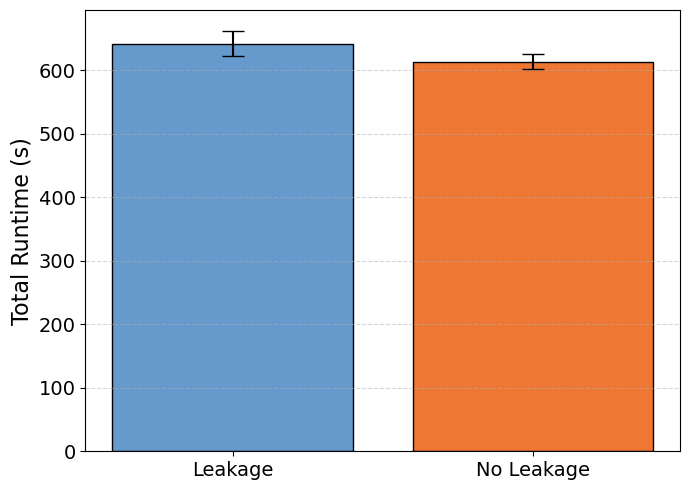

Leakage: mean=641.64s, std=20.03s
No Leakage: mean=613.38s, std=11.90s


In [25]:
# List subfolders and sort by their leading number (1-10)
all_subfolders = [
    f
    for f in os.listdir(folder_to_benchmark)
    if os.path.isdir(os.path.join(folder_to_benchmark, f))
]


# Extract the integer at the start for correct sorting
def get_run_number(foldername):
    try:
        return int(foldername.split("_")[0])
    except ValueError:
        return float("inf")


all_subfolders = sorted(all_subfolders, key=get_run_number)

# Classify runs
categories = []
for i, folder in enumerate(all_subfolders, 1):
    if 1 <= i <= 5:
        categories.append("Leakage")
    elif 6 <= i <= 10:
        categories.append("No Leakage")
    else:
        categories.append("Unknown")

runtimes = {"Leakage": [], "No Leakage": []}

for folder, category in zip(all_subfolders, categories):
    file_path = os.path.join(
        folder_to_benchmark, folder, "model_info", "model_info.csv"
    )
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep=None, engine="python")
        runtime = df.loc[0, "Total Time (s)"]
        if category in runtimes:
            runtimes[category].append(runtime)
    else:
        print(f"Missing: {file_path}")

# Compute means and stds
labels = ["Leakage", "No Leakage"]
means = [np.mean(runtimes[label]) for label in labels]
stds = [np.std(runtimes[label]) for label in labels]

# Plot
plt.figure(figsize=(7, 5))
plt.bar(
    labels, means, yerr=stds, capsize=8, color=["#6699cc", "#ee7733"], edgecolor="black"
)
plt.ylabel("Total Runtime (s)", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Leakage: mean={means[0]:.2f}s, std={stds[0]:.2f}s")
print(f"No Leakage: mean={means[1]:.2f}s, std={stds[1]:.2f}s")

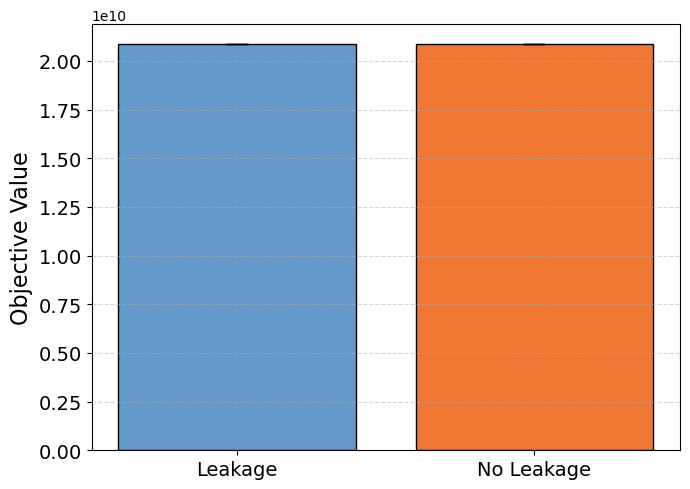

Leakage: mean=20849133429.10712814, std=0.00000
No Leakage: mean=20848386040.65520096, std=0.00000


In [28]:
objvals = {"Leakage": [], "No Leakage": []}

for folder, category in zip(all_subfolders, categories):
    file_path = os.path.join(
        folder_to_benchmark, folder, "model_info", "model_info.csv"
    )
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep=None, engine="python")
        val = df.loc[0, "Objective Value"]
        if category in objvals:
            objvals[category].append(val)
    else:
        print(f"Missing: {file_path}")

# Compute mean and std
labels = ["Leakage", "No Leakage"]
means = [np.mean(objvals[label]) for label in labels]
stds = [np.std(objvals[label]) for label in labels]

# Plot
plt.figure(figsize=(7, 5))
plt.bar(
    labels, means, yerr=stds, capsize=8, color=["#6699cc", "#ee7733"], edgecolor="black"
)
plt.ylabel("Objective Value", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Leakage: mean={means[0]:.8f}, std={stds[0]:.5f}")
print(f"No Leakage: mean={means[1]:.8f}, std={stds[1]:.5f}")